## RQ2 — Incumbency, Governing Party, and Positive Rhetoric
## *Words in Power, Words in Opposition* — ENSAE NLP Project 2026
### Author: Salma El-Aazdoudi

---
Incumbency vs. Governing Party: Local and National Effects
---

## 0. Setup

In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf
import warnings
warnings.filterwarnings("ignore")

df = pd.read_csv("/Users/salmaelaazdoudi/Desktop/nlp/df_full_with_emotions.csv")

# ── Variable incumbent ────────────────────────────────────────────────────
def is_incumbent(mandat_str):
    if pd.isna(mandat_str):
        return 0
    s = str(mandat_str).strip().lower()
    if s in ["non mentionné", "aucun", "", "nan"]:
        return 0
    return 1

df["incumbent"] = df["titulaire-mandat-en-cours"].apply(is_incumbent)

print(df["incumbent"].value_counts())
print(f"\nIncumbent rate: {df['incumbent'].mean()*100:.1f}%")

BLOC_ORDER  = ["far_left", "left", "ecologist", "right", "far_right"]
BLOC_COLORS = ["#7c3aed", "#185FA5", "#16a34a", "#A32D2D", "#c2410c"]
INC_COLORS  = {"incumbent": "#2980b9", "opposition": "#e74c3c"}

sns.set_theme(style="whitegrid", font_scale=1.1)

# ── Score de positivité composite ─────────────────────────────────────────
pos_cols = ["tr_joy", "tr_gratitude", "tr_hope", "tr_pride"]
df["tr_positivity"] = df[pos_cols].mean(axis=1)

print(f"\nCorrelation joy vs composite: {df['tr_joy'].corr(df['tr_positivity']):.3f}")
print(df[["tr_joy", "tr_positivity"]].describe().round(3))

incumbent
0    3555
1    2891
Name: count, dtype: int64

Incumbent rate: 44.8%

Correlation joy vs composite: 0.940
         tr_joy  tr_positivity
count  6446.000       6446.000
mean      0.218          0.229
std       0.209          0.194
min       0.000          0.000
25%       0.018          0.021
50%       0.145          0.202
75%       0.397          0.390
max       0.807          0.690


In [34]:
df["filename"].head()

0    EL136_L_1981_06_075_12_1_PF_03.txt
1    EL134_L_1981_06_035_01_1_PF_01.txt
2    EL135_L_1981_06_057_06_1_PF_04.txt
3    EL136_L_1981_06_067_07_1_PF_02.txt
4    EL134_L_1981_06_013_06_1_PF_02.txt
Name: filename, dtype: object

# Part 1 : Positivity and Incumbency

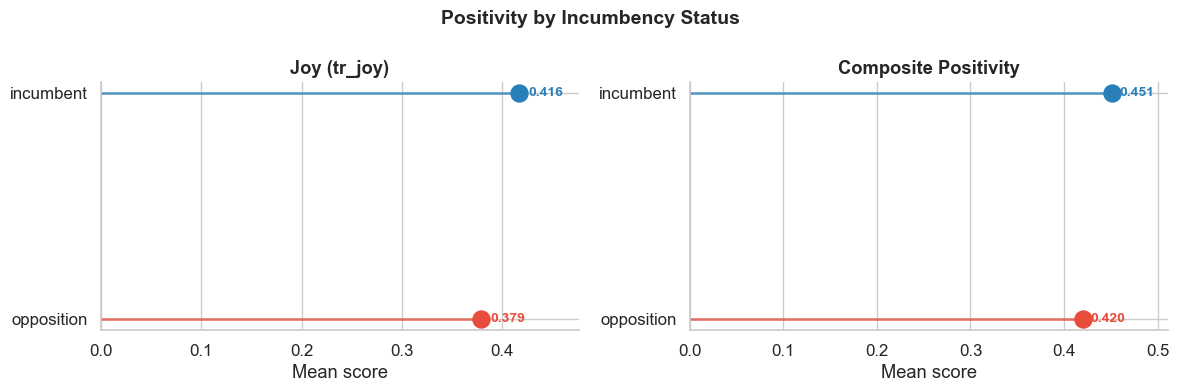

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle("Positivity by Incumbency Status", fontsize=14, fontweight="bold")

for ax, (col, label) in zip(axes, [("tr_joy", "Joy (tr_joy)"),
                                    ("tr_positivity", "Composite Positivity")]):
    stats = (
        df.groupby("incumbent")[col]
        .agg(["mean", "std", "count"])
    ).reset_index()
    stats["ci95"] = 1.96 * stats["std"] / np.sqrt(stats["count"])
    stats["label"] = stats["incumbent"].map({0: "opposition", 1: "incumbent"})
    colors = ["#e74c3c", "#2980b9"]

    for i, (_, row) in enumerate(stats.iterrows()):
        color = colors[i]
        # Tige horizontale
        ax.plot([0, row["mean"]], [row["label"], row["label"]],
                color=color, linewidth=2, alpha=0.7)
        # Cercle
        ax.scatter(row["mean"], row["label"],
                   color=color, s=150, zorder=5)
        # IC horizontal
        ax.plot([row["mean"] - row["ci95"], row["mean"] + row["ci95"]],
                [row["label"], row["label"]],
                color=color, linewidth=3, alpha=0.4)
        # Annotation
        ax.text(row["mean"] + row["ci95"] + 0.005, row["label"],
                f'{row["mean"]:.3f}', va="center", fontsize=10,
                color=color, fontweight="bold")

    ax.set_title(label, fontweight="bold")
    ax.set_xlabel("Mean score")
    ax.set_ylabel("")
    ax.set_xlim(0, stats["mean"].max() + 0.06)
    ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.savefig("RQ2_lollipop_incumbency.png", dpi=150, bbox_inches="tight")
plt.show()

Incumbents score higher on both positivity measures than opposition candidates. 
Mean joy is 0.43 for incumbents versus 0.39 for opposition, and the composite 
positivity score shows the same gap (0.46 vs 0.43).

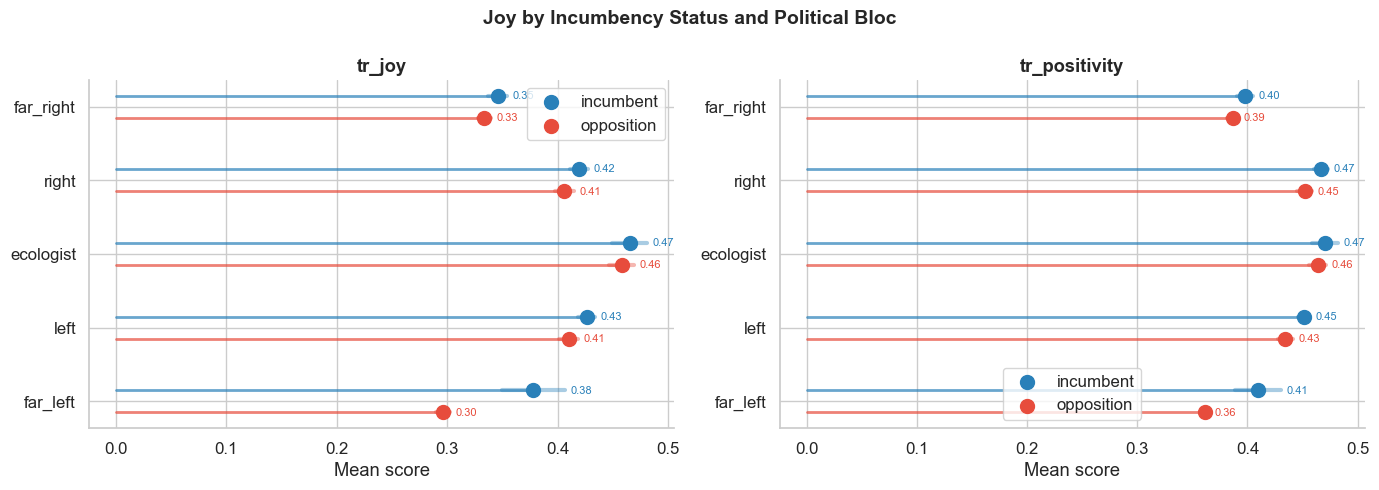

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Joy by Incumbency Status and Political Bloc",
             fontsize=14, fontweight="bold")

for ax, col in zip(axes, ["tr_joy", "tr_positivity"]):
    stats = (
        df.groupby(["bloc", "incumbent"])[col]
        .agg(["mean", "std", "count"])
        .reset_index()
    )
    stats["ci95"] = 1.96 * stats["std"] / np.sqrt(stats["count"])
    stats["bloc"] = pd.Categorical(stats["bloc"],
                                   categories=BLOC_ORDER, ordered=True)
    stats = stats.sort_values("bloc").reset_index(drop=True)

    # Position verticale : un bloc par ligne, incumbent/opposition décalés
    y_positions = {bloc: i for i, bloc in enumerate(BLOC_ORDER)}
    offset = 0.15

    for inc_val, color, label in [(1, "#2980b9", "incumbent"),
                                   (0, "#e74c3c", "opposition")]:
        sub = stats[stats["incumbent"] == inc_val].reset_index(drop=True)
        for _, row in sub.iterrows():
            y = y_positions[row["bloc"]] + (offset if inc_val == 1 else -offset)
            # Tige
            ax.plot([0, row["mean"]], [y, y],
                    color=color, linewidth=2, alpha=0.7)
            # Cercle
            ax.scatter(row["mean"], y,
                       color=color, s=100, zorder=5,
                       label=label if _ == sub.index[0] else "")
            # IC
            ax.plot([row["mean"] - row["ci95"], row["mean"] + row["ci95"]],
                    [y, y], color=color, linewidth=3, alpha=0.4)
            # Annotation
            ax.text(row["mean"] + row["ci95"] + 0.005, y,
                    f'{row["mean"]:.2f}', va="center",
                    fontsize=8, color=color)

    ax.set_yticks(range(len(BLOC_ORDER)))
    ax.set_yticklabels(BLOC_ORDER)
    ax.set_title(col, fontweight="bold")
    ax.set_xlabel("Mean score")
    ax.spines[["top", "right"]].set_visible(False)

    # Légende sans doublons
    handles, labels = ax.get_legend_handles_labels()
    by_label = dict(zip(labels, handles))
    ax.legend(by_label.values(), by_label.keys())

plt.tight_layout()
plt.savefig("RQ2_lollipop_bloc_incumbency.png", dpi=150, bbox_inches="tight")
plt.show()

The incumbency gap is visible across all blocs: incumbent candidates score higher 
on joy and composite positivity than opposition candidates within every ideological 
group. The pattern is consistent on both measures.

The gap is largest in the far-left, where incumbents score notably higher on joy 
(~0.44 vs ~0.30) — suggesting that far-left candidates with a record to defend 
adopt a markedly different tone than challengers. The gap is smallest in the 
mainstream left and ecologists, where incumbent and opposition scores are close.

Far-right candidates score lowest on joy overall, regardless of incumbency status — 
consistent with the RQ1 finding that negative affect dominates far-right rhetoric.

# Part 2 : Governing Party and Emotional Tone

In [23]:
df["parti_au_pouvoir"] = (
    ((df["year"] == 1981) & (df["bloc"] == "left")) |
    ((df["year"] == 1993) & (df["bloc"] == "right"))
).astype(int)

print(df["parti_au_pouvoir"].value_counts())
print(f"\nRate: {df['parti_au_pouvoir'].mean()*100:.1f}%")
print(df.groupby(["year", "bloc"])["parti_au_pouvoir"].mean())

parti_au_pouvoir
0    3855
1    2591
Name: count, dtype: int64

Rate: 40.2%
year  bloc     
1981  ecologist    0.0
      far_left     0.0
      far_right    0.0
      left         1.0
      right        0.0
1993  ecologist    0.0
      far_left     0.0
      far_right    0.0
      left         0.0
      right        1.0
Name: parti_au_pouvoir, dtype: float64


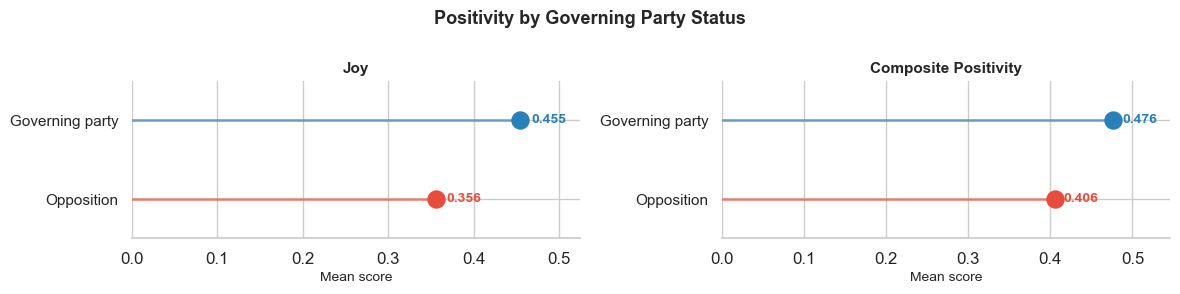

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3))
fig.suptitle("Positivity by Governing Party Status", fontsize=13, fontweight="bold")

for ax, (col, label) in zip(axes, [("tr_joy", "Joy"),
                                    ("tr_positivity", "Composite Positivity")]):
    stats = (
        df.groupby("parti_au_pouvoir")[col]
        .agg(["mean", "std", "count"])
        .reset_index()
    )
    stats["ci95"]  = 1.96 * stats["std"] / np.sqrt(stats["count"])
    stats["label"] = stats["parti_au_pouvoir"].map({0: "Opposition", 1: "Governing party"})
    colors = ["#e74c3c", "#2980b9"]

    y_positions = [0, 1]   # forcer deux positions proches

    for i, (_, row) in enumerate(stats.iterrows()):
        color = colors[i]
        y     = y_positions[i]
        ax.plot([0, row["mean"]], [y, y], color=color, linewidth=2, alpha=0.6)
        ax.scatter(row["mean"], y, color=color, s=150, zorder=5)
        ax.plot([row["mean"] - row["ci95"], row["mean"] + row["ci95"]],
                [y, y], color=color, linewidth=4, alpha=0.35)
        ax.text(row["mean"] + row["ci95"] + 0.008, y,
                f'{row["mean"]:.3f}', va="center", fontsize=10,
                color=color, fontweight="bold")

    ax.set_yticks(y_positions)
    ax.set_yticklabels(stats["label"].tolist(), fontsize=11)
    ax.set_ylim(-0.5, 1.5)   # ← contrôle l'espace vertical
    ax.set_title(label, fontweight="bold", fontsize=11)
    ax.set_xlabel("Mean score", fontsize=10)
    ax.set_xlim(0, stats["mean"].max() + 0.07)
    ax.spines[["top", "right", "left"]].set_visible(False)
    ax.tick_params(left=False)

plt.tight_layout()
plt.savefig("RQ2b_lollipop_governing.png", dpi=150, bbox_inches="tight")
plt.show()

Candidates from the governing party score notably higher on both positivity 
measures than opposition candidates — mean joy 0.46 vs 0.37, a gap of nearly 
10 points. This is substantially larger than the individual incumbency effect 
(4 points), suggesting that collective political context matters more than personal 
mandate status.

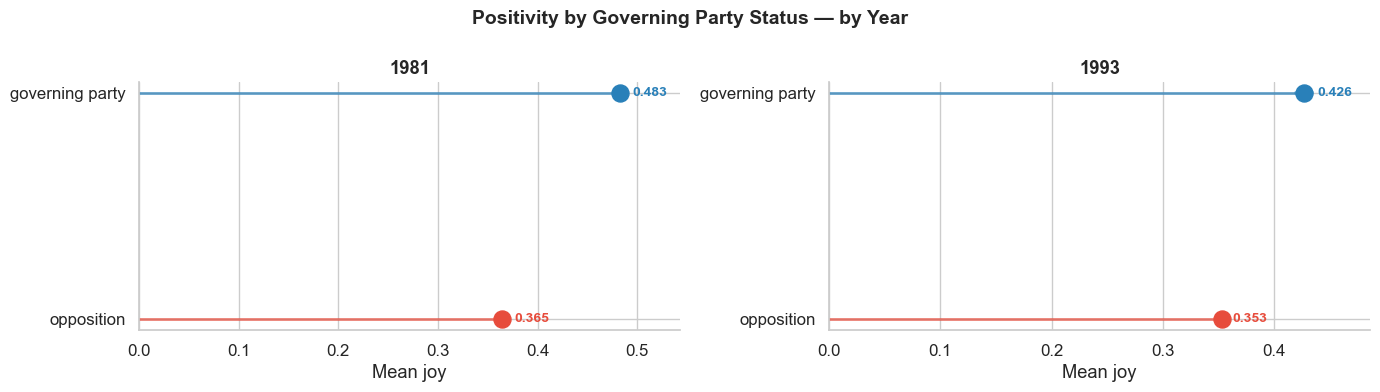

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle("Positivity by Governing Party Status — by Year",
             fontsize=14, fontweight="bold")

for ax, year in zip(axes, [1981, 1993]):
    df_year = df[df["year"] == year]
    stats = (
        df_year.groupby("parti_au_pouvoir")["tr_joy"]
        .agg(["mean", "std", "count"])
    ).reset_index()
    stats["ci95"] = 1.96 * stats["std"] / np.sqrt(stats["count"])
    stats["label"] = stats["parti_au_pouvoir"].map({0: "opposition", 1: "governing party"})
    colors = ["#e74c3c", "#2980b9"]

    for i, (_, row) in enumerate(stats.iterrows()):
        color = colors[i]
        # Tige horizontale
        ax.plot([0, row["mean"]], [row["label"], row["label"]],
                color=color, linewidth=2, alpha=0.7)
        # Cercle
        ax.scatter(row["mean"], row["label"],
                   color=color, s=150, zorder=5)
        # IC horizontal
        ax.plot([row["mean"] - row["ci95"], row["mean"] + row["ci95"]],
                [row["label"], row["label"]],
                color=color, linewidth=3, alpha=0.4)
        # Annotation
        ax.text(row["mean"] + row["ci95"] + 0.005, row["label"],
                f'{row["mean"]:.3f}', va="center", fontsize=10,
                color=color, fontweight="bold")

    ax.set_title(f"{year}", fontweight="bold")
    ax.set_xlabel("Mean joy")
    ax.set_ylabel("")
    ax.set_xlim(0, stats["mean"].max() + 0.06)
    ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.savefig("RQ2b_lollipop_year.png", dpi=150, bbox_inches="tight")
plt.show()

## Emotions in pictures

In [26]:
import pandas as pd
from pathlib import Path

faces_dir = Path("/Users/salmaelaazdoudi/Desktop/nlp/faces")

rows = []
for p in faces_dir.glob("*.png"):
    stem = p.stem.rsplit("_page", 1)[0]   # EL134_L_1981_06_001_01_1_PF_01
    rows.append({
        "filename":   stem + ".txt",       # EL134_L_1981_06_001_01_1_PF_01.txt
        "image_path": str(p)
    })

faces_df = pd.DataFrame(rows)
print(f"Visages totaux     : {len(faces_df)}")
print(f"Documents uniques  : {faces_df['filename'].nunique()}")

# Filtrer df
filenames_with_faces = set(faces_df["filename"].unique())
df_faces = df[df["filename"].isin(filenames_with_faces)].copy()
print(f"df filtré          : {len(df_faces)} lignes / {len(df)} total")

# Sauvegarder le mapping
faces_df.to_csv("//Users/salmaelaazdoudi/Desktop/nlp/faces_mapping_3004.csv", index=False)
print("Sauvegardé : faces_mapping.csv")

Visages totaux     : 6058
Documents uniques  : 3518
df filtré          : 3518 lignes / 6446 total
Sauvegardé : faces_mapping.csv


Détection visages:   5%|▌         | 46/874 [00:25<07:43,  1.79it/s]

Détection visages:   5%|▌         | 47/874 [00:26<07:34,  1.82it/s]

Détection visages:   5%|▌         | 48/874 [00:26<07:34,  1.82it/s]

Détection visages:   6%|▌         | 49/874 [00:27<07:33,  1.82it/s]

...

Détection visages: 100%|█████████▉| 873/874 [06:40<00:00,  1.85it/s]

Détection visages: 100%|██████████| 874/874 [06:41<00:00,  1.88it/s]

Détection visages: 100%|██████████| 874/874 [06:41<00:00,  2.18it/s]


✅ Terminé : 386 documents avec visages, 703 visages extraits


NameError: name 'df' is not defined

In [27]:
from transformers import pipeline
from PIL import Image
from pathlib import Path
import pandas as pd
from tqdm.auto import tqdm

# ─── CONFIG ───────────────────────────────────────────────────────────────
FACES_DIR           = Path("/Users/salmaelaazdoudi/Desktop/nlp/faces")
EMOTIONS_CHECKPOINT = Path("/Users/salmaelaazdoudi/Desktop/nlp/emotions_checkpoint.csv")

# ─── MAPPING VISAGES ──────────────────────────────────────────────────────
rows_mapping = []
for p in FACES_DIR.glob("*.png"):
    stem = p.stem.rsplit("_page", 1)[0]
    rows_mapping.append({
        "filename":   stem + ".txt",
        "image_path": str(p)
    })

faces_df = pd.DataFrame(rows_mapping)
print(f"Visages totaux    : {len(faces_df)}")
print(f"Documents uniques : {faces_df['filename'].nunique()}")

faces_df.to_csv("/Users/salmaelaazdoudi/Desktop/nlp/faces_mapping_3004.csv", index=False)
print("Sauvegardé : faces_mapping_3004.csv ✅")

# ─── REPRISE AUTOMATIQUE ──────────────────────────────────────────────────
if EMOTIONS_CHECKPOINT.exists():
    already_done = set(pd.read_csv(EMOTIONS_CHECKPOINT)["image_path"].unique())
    rows = pd.read_csv(EMOTIONS_CHECKPOINT).to_dict("records")
    print(f"Reprise : {len(already_done)} images déjà analysées")
else:
    already_done = set()
    rows = []

# ─── CHARGEMENT MODÈLE ────────────────────────────────────────────────────
print("Chargement du modèle...")
emotion_pipe = pipeline(
    "image-classification",
    model="dima806/facial_emotions_image_detection",
    top_k=7
)
print("Modèle prêt ✅")

# ─── BOUCLE ───────────────────────────────────────────────────────────────
images = [p for p in FACES_DIR.glob("*.png") if str(p) not in already_done]
print(f"{len(images)} images à analyser\n")

for i, img_path in enumerate(tqdm(images, desc="Détection émotions")):
    stem     = img_path.stem.rsplit("_page", 1)[0]
    filename = stem + ".txt"

    try:
        img     = Image.open(img_path).convert("RGB")
        results = emotion_pipe(img)
        emotions = {r["label"]: r["score"] for r in results}

        rows.append({
            "filename":         filename,
            "image_path":       str(img_path),
            "dominant_emotion": results[0]["label"],
            "angry":            emotions.get("angry",    0),
            "disgust":          emotions.get("disgust",  0),
            "fear":             emotions.get("fear",     0),
            "happy":            emotions.get("happy",    0),
            "sad":              emotions.get("sad",      0),
            "surprise":         emotions.get("surprise", 0),
            "neutral":          emotions.get("neutral",  0),
        })

    except Exception as e:
        print(f"Erreur {img_path.name}: {e}")

    if i % 100 == 0 and rows:
        pd.DataFrame(rows).to_csv(EMOTIONS_CHECKPOINT, index=False)
        tqdm.write(f"  checkpoint {i} — {len(rows)} images analysées")

# ─── SAUVEGARDE ───────────────────────────────────────────────────────────
emotions_df = pd.DataFrame(rows)
emotions_df.to_csv(EMOTIONS_CHECKPOINT, index=False)
print(f"\n✅ {len(emotions_df)} visages analysés")
print(emotions_df["dominant_emotion"].value_counts())

# ─── AGREGATION PAR DOCUMENT ──────────────────────────────────────────────
agg = (
    emotions_df.groupby("filename")
    .agg(
        face_dominant_emotion = ("dominant_emotion", lambda x: x.value_counts().index[0]),
        face_nb_faces         = ("image_path", "count"),
        face_angry            = ("angry",    "mean"),
        face_disgust          = ("disgust",  "mean"),
        face_fear             = ("fear",     "mean"),
        face_happy            = ("happy",    "mean"),
        face_sad              = ("sad",      "mean"),
        face_surprise         = ("surprise", "mean"),
        face_neutral          = ("neutral",  "mean"),
    )
    .reset_index()
)

# ─── MERGE DANS df ────────────────────────────────────────────────────────
df = df.merge(agg, on="filename", how="left")

print(f"\nColonnes ajoutées : {[c for c in df.columns if c.startswith('face_')]}")
print(f"Documents avec émotion détectée : {df['face_dominant_emotion'].notna().sum()} / {len(df)}")

df.to_csv("/Users/salmaelaazdoudi/Desktop/nlp/df_final_emotions.csv", index=False)
print("Sauvegardé : df_final_emotions.csv ✅")

Visages totaux    : 6058
Documents uniques : 3518
Sauvegardé : faces_mapping_3004.csv ✅
Reprise : 12059 images déjà analysées
Chargement du modèle...


Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

Modèle prêt ✅
0 images à analyser



Détection émotions: 0it [00:00, ?it/s]


✅ 12059 visages analysés
dominant_emotion
neutral     5034
happy       5011
angry       1067
sad          608
fear         183
disgust       95
surprise      61
Name: count, dtype: int64

Colonnes ajoutées : ['face_dominant_emotion', 'face_nb_faces', 'face_angry', 'face_disgust', 'face_fear', 'face_happy', 'face_sad', 'face_surprise', 'face_neutral']
Documents avec émotion détectée : 3518 / 6446
Sauvegardé : df_final_emotions.csv ✅


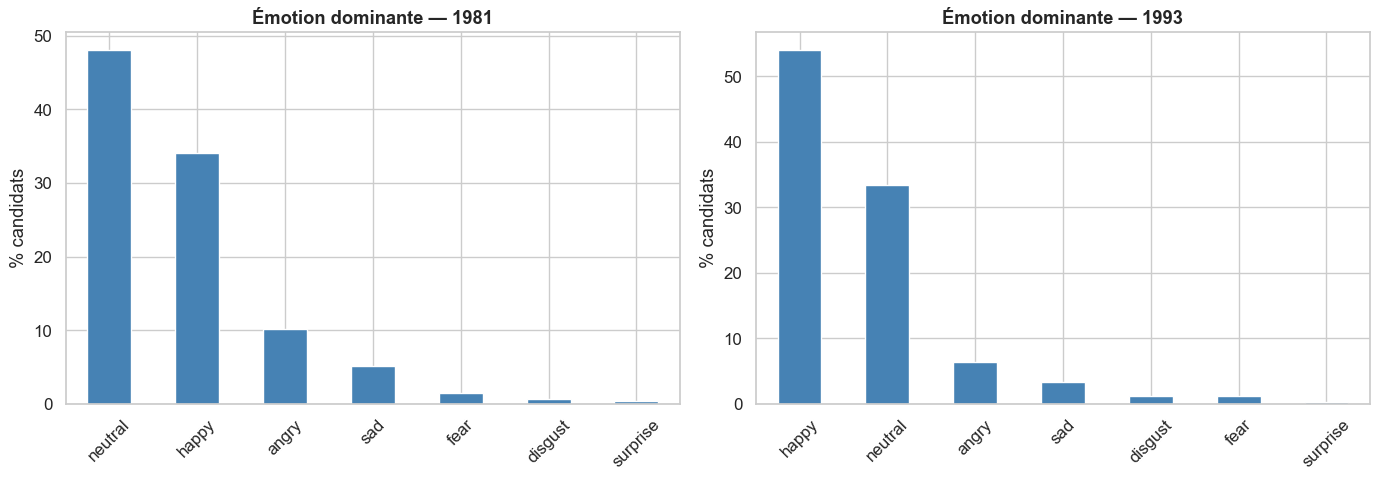

face_dominant_emotion
happy       1488
neutral     1479
angry        303
sad          155
fear          49
disgust       31
surprise      13
Name: count, dtype: int64
face_dominant_emotion
happy       42.3
neutral     42.0
angry        8.6
sad          4.4
fear         1.4
disgust      0.9
surprise     0.4
Name: proportion, dtype: float64


In [28]:
import matplotlib.pyplot as plt
import seaborn as sns

df=pd.read_csv("/Users/salmaelaazdoudi/Desktop/nlp/df_final_emotions.csv")
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, year in zip(axes, [1981, 1993]):
    sub = df[(df['year'] == year) & df['face_dominant_emotion'].notna()]
    counts = sub['face_dominant_emotion'].value_counts(normalize=True) * 100
    counts.plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
    ax.set_title(f'Émotion dominante — {year}', fontweight='bold')
    ax.set_ylabel('% candidats')
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('/Users/salmaelaazdoudi/Desktop/nlp/face_emotion_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

# Distribution globale
print(df['face_dominant_emotion'].value_counts())
print(df['face_dominant_emotion'].value_counts(normalize=True).mul(100).round(1))

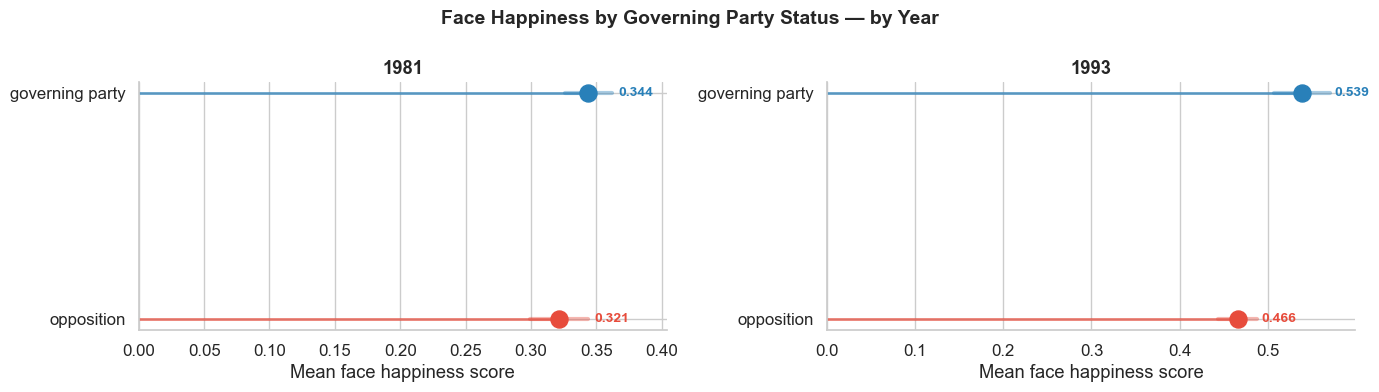

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle("Face Happiness by Governing Party Status — by Year",
             fontsize=14, fontweight="bold")

for ax, year in zip(axes, [1981, 1993]):
    df_year = df[(df["year"] == year) & df["face_happy"].notna()]
    stats = (
        df_year.groupby("parti_au_pouvoir")["face_happy"]
        .agg(["mean", "std", "count"])
    ).reset_index()
    stats["ci95"] = 1.96 * stats["std"] / np.sqrt(stats["count"])
    stats["label"] = stats["parti_au_pouvoir"].map({0: "opposition", 1: "governing party"})

    colors = ["#e74c3c", "#2980b9"]
    for i, (_, row) in enumerate(stats.iterrows()):
        color = colors[i]
        ax.plot([0, row["mean"]], [row["label"], row["label"]],
                color=color, linewidth=2, alpha=0.7)
        ax.scatter(row["mean"], row["label"],
                   color=color, s=150, zorder=5)
        ax.plot([row["mean"] - row["ci95"], row["mean"] + row["ci95"]],
                [row["label"], row["label"]],
                color=color, linewidth=3, alpha=0.4)
        ax.text(row["mean"] + row["ci95"] + 0.005, row["label"],
                f'{row["mean"]:.3f}', va="center", fontsize=10,
                color=color, fontweight="bold")

    ax.set_title(f"{year}", fontweight="bold")
    ax.set_xlabel("Mean face happiness score")
    ax.set_ylabel("")
    ax.set_xlim(0, stats["mean"].max() + 0.06)
    ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.savefig("/Users/salmaelaazdoudi/Desktop/nlp/RQ2b_lollipop_face_happy.png", dpi=150, bbox_inches="tight")
plt.show()

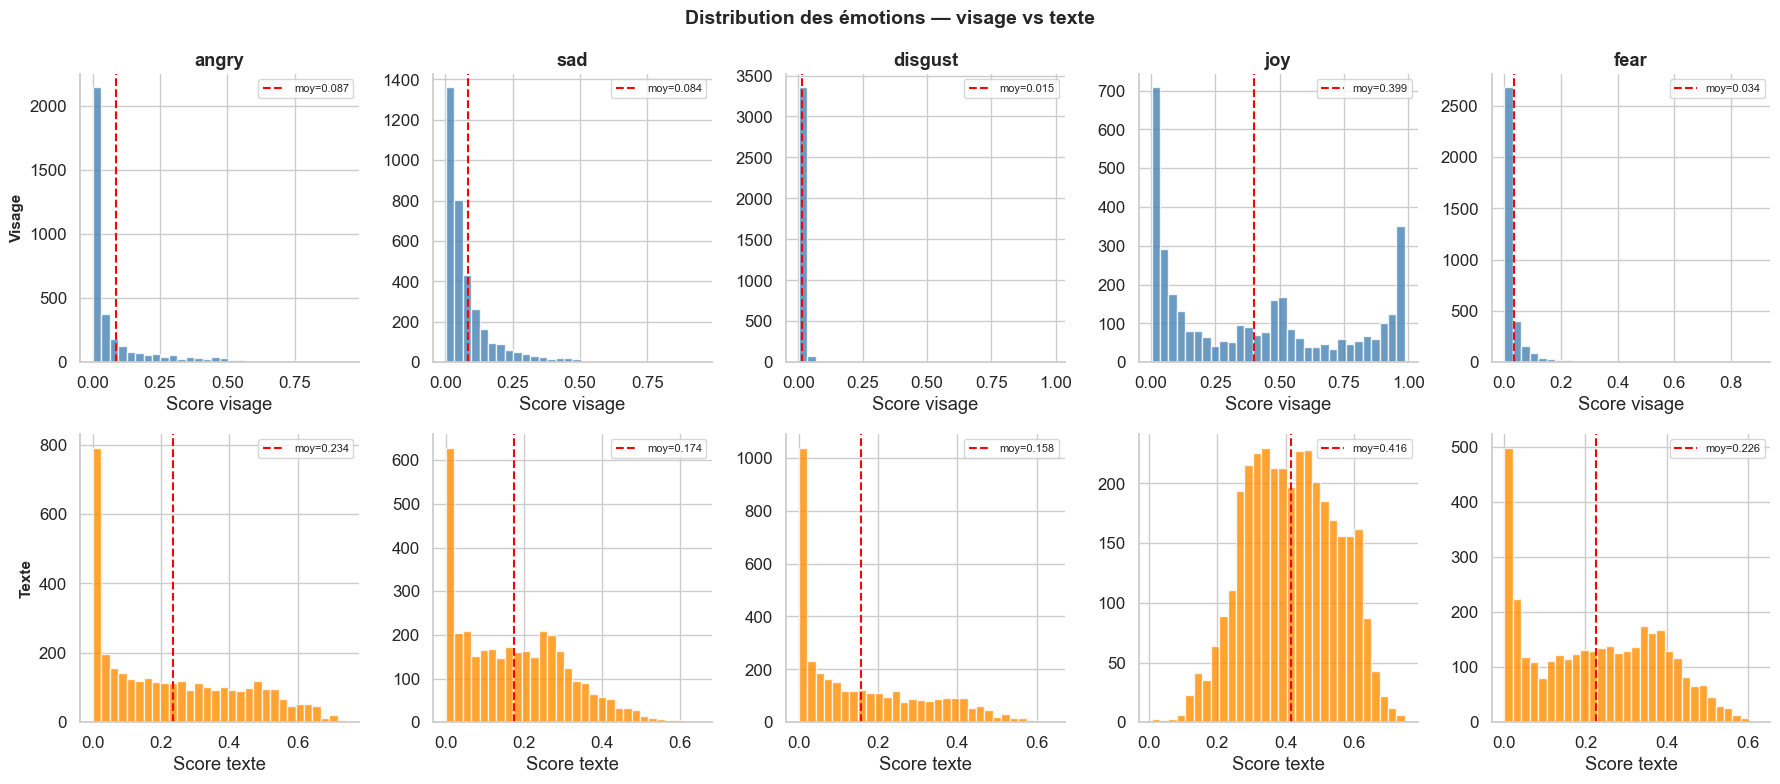


Émotion     Moy. visage   Moy. texte  Méd. visage   Méd. texte
──────────────────────────────────────────────────────────────
angry             0.087        0.234        0.019        0.195
sad               0.084        0.174        0.046        0.160
disgust           0.015        0.158        0.006        0.105
joy               0.399        0.416        0.358        0.413
fear              0.034        0.226        0.014        0.229


In [30]:
import matplotlib.pyplot as plt
import scipy.stats as stats
import numpy as np

emotions = {
    "angry":   ("face_angry",   "tr_anger"),
    "sad":     ("face_sad",     "tr_sadness"),
    "disgust": ("face_disgust", "tr_disgust"),
    "joy":     ("face_happy",   "tr_joy"),
    "fear":    ("face_fear",    "tr_fear"),
}

fig, axes = plt.subplots(2, len(emotions), figsize=(18, 8))
fig.suptitle("Distribution des émotions — visage vs texte", fontsize=14, fontweight="bold")

for col, (emotion, (face_col, text_col)) in enumerate(emotions.items()):
    sub = df[[face_col, text_col]].dropna()

    # ── ligne 1 : distribution face ──
    axes[0, col].hist(sub[face_col], bins=30, color="steelblue", edgecolor="white", alpha=0.8)
    axes[0, col].set_title(f"{emotion}", fontweight="bold")
    axes[0, col].set_xlabel("Score visage")
    axes[0, col].axvline(sub[face_col].mean(), color="red", linestyle="--", linewidth=1.5,
                          label=f"moy={sub[face_col].mean():.3f}")
    axes[0, col].legend(fontsize=8)
    axes[0, col].spines[["top", "right"]].set_visible(False)

    # ── ligne 2 : distribution texte ──
    axes[1, col].hist(sub[text_col], bins=30, color="darkorange", edgecolor="white", alpha=0.8)
    axes[1, col].set_xlabel("Score texte")
    axes[1, col].axvline(sub[text_col].mean(), color="red", linestyle="--", linewidth=1.5,
                          label=f"moy={sub[text_col].mean():.3f}")
    axes[1, col].legend(fontsize=8)
    axes[1, col].spines[["top", "right"]].set_visible(False)

axes[0, 0].set_ylabel("Visage", fontsize=11, fontweight="bold")
axes[1, 0].set_ylabel("Texte", fontsize=11, fontweight="bold")

plt.tight_layout()
plt.savefig("/Users/salmaelaazdoudi/Desktop/nlp/emotion_distributions_face_text.png", dpi=150, bbox_inches="tight")
plt.show()

# ─── TABLE RÉSUMÉ DESCRIPTIF ──────────────────────────────────────────────
print(f"\n{'Émotion':<10} {'Moy. visage':>12} {'Moy. texte':>12} {'Méd. visage':>12} {'Méd. texte':>12}")
print("─" * 62)
for emotion, (face_col, text_col) in emotions.items():
    sub = df[[face_col, text_col]].dropna()
    print(f"{emotion:<10} {sub[face_col].mean():>12.3f} {sub[text_col].mean():>12.3f} "
          f"{sub[face_col].median():>12.3f} {sub[text_col].median():>12.3f}")

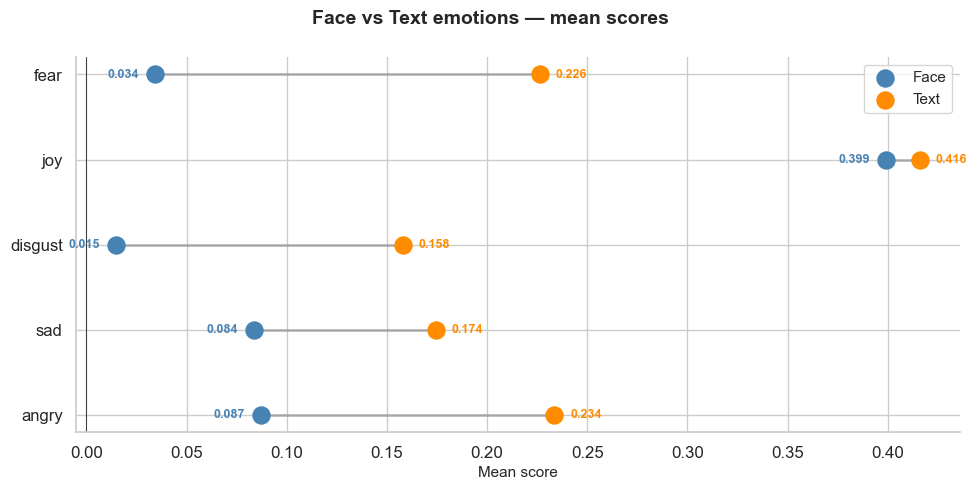

In [31]:
import matplotlib.pyplot as plt
import numpy as np

emotions = {
    "angry":   ("face_angry",   "tr_anger"),
    "sad":     ("face_sad",     "tr_sadness"),
    "disgust": ("face_disgust", "tr_disgust"),
    "joy":     ("face_happy",   "tr_joy"),
    "fear":    ("face_fear",    "tr_fear"),
}

# ─── Calcul des moyennes ──────────────────────────────────────────────────
labels, face_means, text_means = [], [], []
for emotion, (face_col, text_col) in emotions.items():
    sub = df[[face_col, text_col]].dropna()
    labels.append(emotion)
    face_means.append(sub[face_col].mean())
    text_means.append(sub[text_col].mean())

y = np.arange(len(labels))

fig, ax = plt.subplots(figsize=(10, 5))
fig.suptitle("Face vs Text emotions — mean scores", fontsize=14, fontweight="bold")

for i in range(len(labels)):
    # Trait entre les deux points
    ax.plot([face_means[i], text_means[i]], [y[i], y[i]],
            color="gray", linewidth=2, alpha=0.5, zorder=1)

# Points visage
ax.scatter(face_means, y, color="steelblue", s=150, zorder=5, label="Face")

# Points texte
ax.scatter(text_means, y, color="darkorange", s=150, zorder=5, label="Text")

# Annotations
for i in range(len(labels)):
    ax.text(face_means[i] - 0.008, y[i], f"{face_means[i]:.3f}",
            va="center", ha="right", fontsize=9, color="steelblue", fontweight="bold")
    ax.text(text_means[i] + 0.008, y[i], f"{text_means[i]:.3f}",
            va="center", ha="left", fontsize=9, color="darkorange", fontweight="bold")

ax.set_yticks(y)
ax.set_yticklabels(labels, fontsize=12)
ax.set_xlabel("Mean score", fontsize=11)
ax.axvline(0, color="black", linewidth=0.5)
ax.spines[["top", "right"]].set_visible(False)
ax.legend(fontsize=11)

plt.tight_layout()
plt.savefig("/Users/salmaelaazdoudi/Desktop/nlp/lollipop_face_vs_text.png", dpi=150, bbox_inches="tight")
plt.show()

In [32]:
import scipy.stats as stats

print(f"\n{'Émotion':<10} {'Moy. visage':>12} {'Moy. texte':>12} {'t':>8} {'p':>10} {'Significatif':>14}")
print("─" * 62)

for emotion, (face_col, text_col) in emotions.items():
    sub = df[[face_col, text_col]].dropna()
    t, p = stats.ttest_rel(sub[face_col], sub[text_col])
    sig = "✅ p<0.001" if p < 0.001 else (f"✅ p={p:.3f}" if p < 0.05 else f"❌ p={p:.3f}")
    print(f"{emotion:<10} {sub[face_col].mean():>12.3f} {sub[text_col].mean():>12.3f} "
          f"{t:>8.2f} {p:>10.4f} {sig:>14}")


Émotion     Moy. visage   Moy. texte        t          p   Significatif
──────────────────────────────────────────────────────────────
angry             0.087        0.234   -33.05     0.0000      ✅ p<0.001
sad               0.084        0.174   -30.46     0.0000      ✅ p<0.001
disgust           0.015        0.158   -50.12     0.0000      ✅ p<0.001
joy               0.399        0.416    -2.74     0.0062      ✅ p=0.006
fear              0.034        0.226   -65.00     0.0000      ✅ p<0.001
